# 假设检验与差异比较

学习目标：根据问题和抽样设计选择均值检验，理解统计量、p 值与错误率的关系，并结合差异大小、置信区间和模拟结果解释比较结论。

前置知识：抽样分布、样本均值与方差、标准误、t 分布与自由度、区间估计、条件概率；Python 函数与 NumPy 数组操作。

运行环境：Python 3.12、NumPy 2.5、SciPy 1.18、Matplotlib 3.11。

环境准备：[环境配置与运行](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

## 1 从一个均值比较问题开始

### 1.1 假设针对总体参数

某项计算任务的参考平均耗时是 10 ms。给定一组教学数据 $9,10,11,12,13$ ms，我们要判断总体平均耗时是否偏离参考值。它们用于演示计算，不是实际性能测量记录。

记未知总体均值为 $\mu$，参考值为 $\mu_0=10$ ms，提出

$$H_0:\mu=\mu_0,\qquad H_1:\mu\ne\mu_0.$$

$H_0$ 是原假设（null hypothesis），$H_1$ 是备择假设（alternative hypothesis）。比较对象是总体均值，不能把“样本均值是否恰好等于 10”当作检验问题。

本例假设 $X_1,\ldots,X_n$ 独立同分布于 $\mathcal N(\mu,\sigma^2)$，$\sigma>0$ 未知，固定样本量 $n=5$。事先选择双侧检验和显著性水平 $\alpha=0.05$。模型、方向与停止收集数据的规则都属于分析方案。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import t, ttest_1samp, ttest_ind, ttest_rel

sample = np.array([9.0, 10.0, 11.0, 12.0, 13.0])
reference_mean = 10.0
alpha = 0.05
sample_size = sample.size
sample_mean = sample.mean()

print("样本量与均值：", sample_size, sample_mean)  # 预期为 5 11。
print("观察到的平均差异（ms）：", sample_mean - reference_mean)  # 预期为 1。
# 样本均值与参考值相差 1 ms；还需相对于抽样波动判断这个差异。

样本量与均值： 5 11.0
观察到的平均差异（ms）： 1.0


### 1.2 统计量把差异换成标准误单位

独立观测使样本均值的方差为 $\operatorname{Var}(\bar X)=\sigma^2/n$。用样本标准差 $S$ 估计未知的 $\sigma$，得到检验统计量

$$T=\frac{\bar X-\mu_0}{S/\sqrt n},\qquad
S^2=\frac1{n-1}\sum_{i=1}^n(X_i-\bar X)^2.$$

$S/\sqrt n$ 是均值标准误的估计；它与描述单次观测离散程度的 $S$ 不同。在上述正态、独立假设及 $H_0$ 下，$T\sim t_{n-1}$。这个已知分布称为原假设下的分布，简称零分布。

对当前数据，$\bar x=11$，

$$s^2=\frac{(-2)^2+(-1)^2+0^2+1^2+2^2}{4}=2.5,\qquad
t_{\mathrm{obs}}=\frac{11-10}{\sqrt{2.5/5}}=\sqrt2.$$

大写 $T$ 表示随抽样变化的随机统计量，小写 $t_{\mathrm{obs}}$ 表示这次数据算出的数。统计量无量纲，正号表示样本均值高于参考值。

In [2]:
sample_variance = sample.var(ddof=1)
standard_error = np.sqrt(sample_variance / sample_size)
degrees_freedom = sample_size - 1
# 把观测均值与原假设均值之差除以均值标准误，变成无单位的统计量。
observed_t = (sample_mean - reference_mean) / standard_error

print("样本方差（ms²）与均值标准误（ms）：", sample_variance, standard_error)  # 预期约为 2.5 0.707107。
print("t 统计量与自由度：", observed_t, degrees_freedom)  # 预期约为 1.41421 4。
print("与手算 sqrt(2) 的差：", abs(observed_t - np.sqrt(2)))  # 本次数值约为 2.2e-16。

样本方差（ms²）与均值标准误（ms）： 2.5 0.7071067811865476
t 统计量与自由度： 1.414213562373095 4
与手算 sqrt(2) 的差： 2.220446049250313e-16


### 1.3 p 值由零分布的尾部概率得到

双侧备择关注均值向两个方向偏离，因此把绝对统计量作为“更极端”的标准：

$$p=P_{H_0}(|T|\ge|t_{\mathrm{obs}}|)
=2P_{H_0}(T\ge|t_{\mathrm{obs}}|).$$

最后一步利用 t 分布关于 0 的对称性。p 值是在 $H_0$ 及模型条件成立时，统计量至少像当前这么极端的概率；它不是 $P(H_0\mid\text{数据})$，也不是“差异纯属偶然的概率”。

SciPy 的 t.sf 计算右尾概率，避免先求接近 1 的累计概率再相减。ttest_1samp 将同一计算封装起来，返回 statistic、pvalue 和 df。

In [3]:
manual_p = 2 * t.sf(abs(observed_t), df=degrees_freedom)
one_sample_result = ttest_1samp(sample, popmean=reference_mean, alternative="two-sided")

print("手算公式的双侧 p 值：", manual_p)  # 预期约为 0.2302。
# 预期约为 1.41421 0.2302 4。
print(
    "SciPy 的 t、p、df：",
    one_sample_result.statistic,
    one_sample_result.pvalue,
    one_sample_result.df,
)
print("两种 p 值算法的绝对差：", abs(manual_p - one_sample_result.pvalue))  # 预期接近 0；本次计算为 0。
# 约 0.23；这不是“原假设有 23% 的概率成立”。

手算公式的双侧 p 值： 0.2301996410804989
SciPy 的 t、p、df： 1.414213562373095 0.2301996410804989 4
两种 p 值算法的绝对差： 0.0


## 2 显著性水平、检验方向与结论

### 2.1 显著性水平属于事先确定的规则

显著性水平 $\alpha\in(0,1)$ 是检验方案要控制的第一类错误率上界，即 $H_0$ 为真时错误拒绝它的概率上界。在本例的精确 t 检验条件下，双侧规则 $p<\alpha$ 对应

$$|T|>t_{1-\alpha/2,\nu},\qquad \nu=n-1,$$

其中 $t_{q,\nu}$ 是自由度为 $\nu$ 的 t 分布的 $q$ 分位数。阈值由 $\alpha$ 决定，观察到的数据决定 p 值。

本章采用严格小于的拒绝规则；在连续零分布下，恰好落在临界值的概率为 0。若 $p\ge\alpha$，写“在该模型和显著性水平下未拒绝 $H_0$”，不能写“证明相等”或“接受 $H_0$ 为真”。

In [4]:
critical_t = t.ppf(1 - alpha / 2, df=degrees_freedom)
print("双侧临界值：", critical_t)  # 预期约为 2.77645。
print("按 p 值拒绝：", manual_p < alpha)  # 预期为 False。
print("按拒绝域拒绝：", abs(observed_t) > critical_t)  # 预期为 False。

# 按事先固定的 alpha 应用拒绝规则；未拒绝并不等于证明均值相等。
if manual_p < alpha:
    print("在给定模型与 alpha=0.05 下拒绝总体均值为 10 ms。")
else:
    print("在给定模型与 alpha=0.05 下未拒绝总体均值为 10 ms；没有证明相等。")

双侧临界值： 2.7764451051977934
按 p 值拒绝： False
按拒绝域拒绝： False
在给定模型与 alpha=0.05 下未拒绝总体均值为 10 ms；没有证明相等。


### 2.2 p 值与显著性水平对应不同阴影

左图的阴影从本次 $\pm|t_{\mathrm{obs}}|$ 向两侧延伸，表示 p 值；右图从固定的双侧临界值向两侧延伸，表示 $\alpha$。图形只截取有限横轴范围，尾部在数学上继续延伸。

两幅图都使用 $H_0$ 下的 t 密度，没有把 $H_0$ 当作随机变量来画。改变样本会改变左图的起点，事先规定的 $\alpha$ 不随这次样本改变。

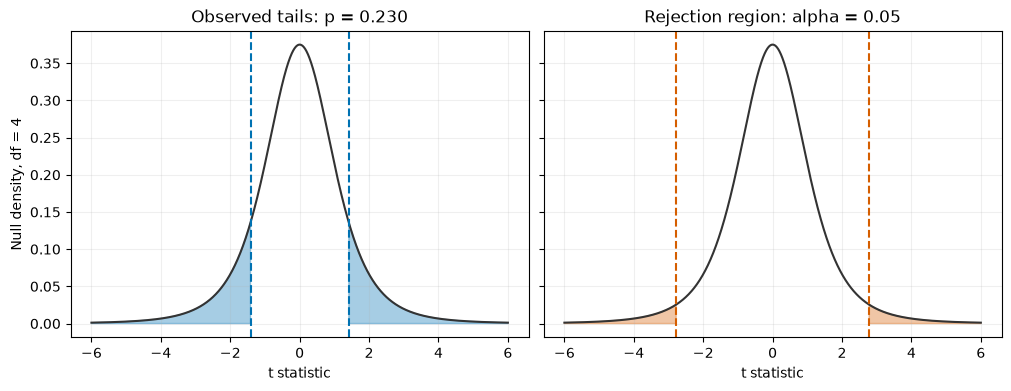

In [5]:
t_grid = np.linspace(-6, 6, 2001)
null_density = t.pdf(t_grid, df=degrees_freedom)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True, layout="constrained")

# 两幅图共用零假设密度；只改变阴影边界，分别对应观测值和预设临界值。
for ax, boundary, title, color in zip(
    axes,
    [abs(observed_t), critical_t],
    [f"Observed tails: p = {manual_p:.3f}", f"Rejection region: alpha = {alpha:.2f}"],
    ["#0072B2", "#D55E00"],
):
    ax.plot(t_grid, null_density, color="#333333")
    # 双侧事件同时包含正负两端，因此用绝对值与边界比较。
    ax.fill_between(
        t_grid, null_density, where=np.abs(t_grid) >= boundary, color=color, alpha=0.35
    )
    ax.axvline(-boundary, color=color, ls="--")
    ax.axvline(boundary, color=color, ls="--")
    ax.set(xlabel="t statistic", title=title)
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Null density, df = 4")
# 预期两幅图都着色左右双尾；观测值对应的尾部面积约 0.2302，大于拒绝域面积 0.05。
plt.show()

### 2.3 单侧与双侧回答不同问题

假设方向取决于研究问题，在看数据之前确定。

| 备择假设 | 原假设 | p 值的尾部 |
| --- | --- | --- |
| $\mu\ne\mu_0$ | $\mu=\mu_0$ | $P(|T|\ge|t_{\mathrm{obs}}|)$ |
| $\mu>\mu_0$ | $\mu\le\mu_0$ | $P(T\ge t_{\mathrm{obs}})$ |
| $\mu<\mu_0$ | $\mu\ge\mu_0$ | $P(T\le t_{\mathrm{obs}})$ |

这里单侧 t 检验在边界 $\mu=\mu_0$ 下校准尾部概率。SciPy 的 alternative 分别使用 two-sided、greater、less。

对于当前正的 $t_{\mathrm{obs}}$，右侧 p 值是双侧值的一半，左侧值却接近 1。不能把任何预先指定的单侧 p 值都算成“双侧除以二”，也不能看到差异方向后选择较小的一侧。下面只对照三种不同问题的计算。

In [6]:
# 保持数据和零假设均值不变，仅比较三种备择方向对应的尾概率。
for alternative in ("two-sided", "greater", "less"):
    result = ttest_1samp(sample, popmean=reference_mean, alternative=alternative)
    print(f"{alternative:9s}：p={result.pvalue:.6f}")  # 双侧、右侧、左侧 p 值依次约为 0.230200、0.115100、0.884900。

# 预期约为 0.1151 0.8849。
print(
    "手动右尾与左尾：",
    t.sf(observed_t, degrees_freedom),
    t.cdf(observed_t, degrees_freedom),
)

two-sided：p=0.230200
greater  ：p=0.115100
less     ：p=0.884900
手动右尾与左尾： 0.11509982054024945 0.8849001794597505


## 3 两类错误与检验功效

### 3.1 错误率是重复抽样下的条件概率

| 检验决定 | $H_0$ 为真 | 某个备择情形为真 |
| --- | --- | --- |
| 拒绝 $H_0$ | 第一类错误（Type I error） | 正确拒绝 |
| 未拒绝 $H_0$ | 正确未拒绝 | 第二类错误（Type II error） |

对一个明确的真实参数 $\mu_1\ne\mu_0$，记第二类错误率为 $\beta(\mu_1)$，则检验功效（power）为

$$\operatorname{Power}(\mu_1)=P_{\mu_1}(\text{拒绝 }H_0)=1-\beta(\mu_1).$$

功效随真实差异、方差、样本量、方向和 $\alpha$ 改变，不是只凭当前 p 值就能读出的一个数。$\alpha=0.05$ 也不表示“这次结论有 5% 的概率错误”。

先在 $H_0$ 为真的已知模型 $X_i\sim\mathcal N(0,1)$ 下，每次独立抽 20 个观测，重复 10000 次。每一行是一场完整实验，用双侧单样本 t 检验观察虚假拒绝频率。

In [7]:
null_rng = np.random.default_rng(2103)
repetitions = 10000
null_samples = null_rng.normal(loc=0.0, scale=1.0, size=(repetitions, 20))
null_results = ttest_1samp(null_samples, popmean=0.0, axis=1, alternative="two-sided")
false_rejections = null_results.pvalue < alpha
false_rejection_rate = false_rejections.mean()
null_mc_se = np.sqrt(alpha * (1 - alpha) / repetitions)

print("模拟第一类错误率：", false_rejection_rate)  # 本次固定种子下约为 0.0474。
print("理论水平与该水平下的模拟标准误：", alpha, null_mc_se)  # 预期约为 0.05 0.00217945。
# 观察频率应在 0.05 附近波动；有限模拟不要求恰好等于 0.05。

模拟第一类错误率： 0.0474
理论水平与该水平下的模拟标准误： 0.05 0.0021794494717703367


### 3.2 改变样本量与真实差异

仍检验 $H_0:\mu=0$ 对 $H_1:\mu\ne0$，总体标准差固定为 1。令真实均值差异 $\delta\in\{0,0.2,0.5,0.8\}$，样本量 $n\in\{10,30,80\}$。每种组合独立重复 6000 次，每次重新估计标准差。

若 $\delta=0$，拒绝频率估计第一类错误率；若 $\delta\ne0$，它估计该差异下的功效。一般在其他条件固定时，更大的样本量或更明显的差异更容易被检出，但某一次抽样不保证 p 值单调变化。

拒绝指示量取值为 0 或 1。独立重复 $R$ 次时，拒绝频率 $\hat\pi$ 的模拟标准误可估计为 $\sqrt{\hat\pi(1-\hat\pi)/R}$。这里的误差描述模拟次数有限带来的波动，不是原始观测均值的标准误。若模拟频率恰好为 0 或 1，这个代入估计也为 0，但有限次模拟不能证明真实概率恰好达到边界。

In [8]:
power_rng = np.random.default_rng(2132)
power_repetitions = 6000
sample_sizes = [10, 30, 80]
true_differences = np.array([0.0, 0.2, 0.5, 0.8])
rejection_rates = np.empty((len(sample_sizes), len(true_differences)))
simulation_errors = np.empty_like(rejection_rates)

# 外层改变样本量，内层改变真实差异；每次矩阵的一行是一组独立样本。
for row, size in enumerate(sample_sizes):
    for column, difference in enumerate(true_differences):
        simulated = power_rng.normal(difference, 1.0, size=(power_repetitions, size))
        # 沿每行做一次检验，再跨重复实验统计拒绝比例及其模拟标准误。
        p_values = ttest_1samp(simulated, popmean=0.0, axis=1).pvalue
        rate = np.mean(p_values < alpha)
        rejection_rates[row, column] = rate
        simulation_errors[row, column] = np.sqrt(rate * (1 - rate) / power_repetitions)
    # 本次零差异列约为 0.05；差异 0.8 时三种样本量的拒绝率约 0.6075、0.9867、1。
    print(f"n={size}，按 delta=0, 0.2, 0.5, 0.8 排列的拒绝率：", rejection_rates[row])

print("这批模拟的最大标准误：", simulation_errors.max())  # 本次固定种子下约为 0.00636793。

n=10，按 delta=0, 0.2, 0.5, 0.8 排列的拒绝率： [0.0475     0.086      0.29116667 0.6075    ]


n=30，按 delta=0, 0.2, 0.5, 0.8 排列的拒绝率： [0.04733333 0.18166667 0.7525     0.98666667]


n=80，按 delta=0, 0.2, 0.5, 0.8 排列的拒绝率： [0.05       0.41816667 0.99266667 1.        ]
这批模拟的最大标准误： 0.006367931447960627


### 3.3 功效曲线帮助设计实验

将拒绝频率画在同一坐标中。横轴是真实均值差异，纵轴是模拟拒绝比例；$\delta=0$ 处应与虚线 $\alpha=0.05$ 比较，其余位置体现功效。

若事前关心的是 0.2 个单位的差异，就应关注该处的功效，而不是用更容易检出的 0.8 替代它。提高精度通常需要更多独立观测；把同一观测重复复制多次不会增加独立信息。

同一固定样本量下，降低 $\alpha$ 会缩小拒绝域，因而也可能降低功效。应结合错误代价和所需检出能力事先设计实验，而非在看到 p 值后调整阈值。

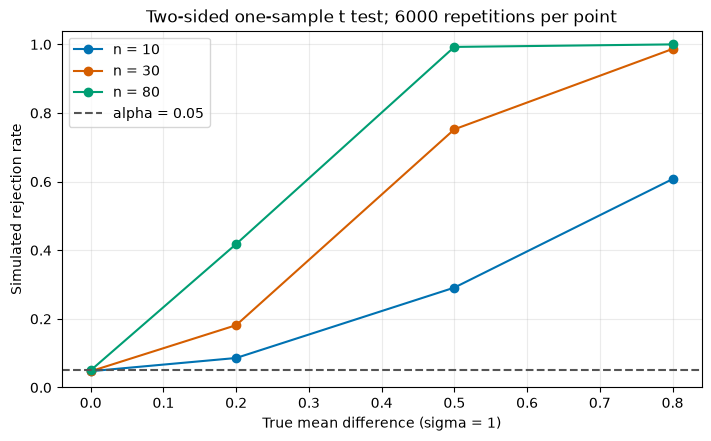

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.3), layout="constrained")
for size, rates, color in zip(
    sample_sizes, rejection_rates, ["#0072B2", "#D55E00", "#009E73"]
):
    ax.plot(true_differences, rates, "o-", color=color, label=f"n = {size}")
ax.axhline(alpha, color="#555555", ls="--", label="alpha = 0.05")
ax.set(
    xlabel="True mean difference (sigma = 1)",
    ylabel="Simulated rejection rate",
    ylim=(0, 1.04),
    title="Two-sided one-sample t test; 6000 repetitions per point",
)
ax.legend()
ax.grid(alpha=0.25)
# 本次零差异处各曲线靠近 0.05；差异增大时拒绝率升高，较大样本的曲线通常更高。
plt.show()

## 4 独立双样本：Welch 与等方差检验

### 4.1 先说明两组数据怎样得到

独立双样本要求两组之间独立，组内观测也各自独立。记两组总体均值为 $\mu_A,\mu_B$，关注差异 $\Delta=\mu_A-\mu_B$，例如 $H_0:\Delta=0$ 对 $H_1:\Delta\ne0$。

本节先假设两组各自来自正态总体，方差未知且不强制相等。记两组样本量为 $n_A,n_B$，总体方差为 $\sigma_A^2,\sigma_B^2>0$。教学数据为 $A=(9,10,11)$ ms、$B=(8,10,12,14,16)$ ms。两组样本量可以不同。

样本方差 $s_A^2,s_B^2$ 不相等，不能单凭这一点证明总体方差不等；相近也不能证明相等。方差假设要结合模型和实验机制说明，不应通过挑选 p 值较小的检验来决定。

In [10]:
group_a = np.array([9.0, 10.0, 11.0])
group_b = np.array([8.0, 10.0, 12.0, 14.0, 16.0])
# 两组允许不同样本量；各自的均值、方差分别计算，差异方向固定为 A-B。
n_a, n_b = group_a.size, group_b.size
variance_a, variance_b = group_a.var(ddof=1), group_b.var(ddof=1)
observed_difference = group_a.mean() - group_b.mean()

print("两组样本量：", n_a, n_b)  # 预期为 3 5。
print("两组均值（ms）：", group_a.mean(), group_b.mean())  # 预期为 10 12。
print("两组样本方差（ms²）：", variance_a, variance_b)  # 给定两组数据的样本方差分别为 1、10 ms²。
print("A-B 的观察差异（ms）：", observed_difference)  # 预期为 -2。

两组样本量： 3 5
两组均值（ms）： 10.0 12.0
两组样本方差（ms²）： 1.0 10.0
A-B 的观察差异（ms）： -2.0


### 4.2 Welch 检验不要求总体等方差

独立性给出 $\operatorname{Var}(\bar X_A-\bar X_B)=\sigma_A^2/n_A+\sigma_B^2/n_B$。将未知方差分别估计，得到

$$SE_W=\sqrt{\frac{s_A^2}{n_A}+\frac{s_B^2}{n_B}},\qquad
t_W=\frac{\bar x_A-\bar x_B-\Delta_0}{SE_W},$$

其中 $\Delta_0$ 是原假设给定的均值差，本例为 0。Welch–Satterthwaite 自由度为

$$\nu_W=\frac{(s_A^2/n_A+s_B^2/n_B)^2}
{(s_A^2/n_A)^2/(n_A-1)+(s_B^2/n_B)^2/(n_B-1)}.$$

即使两总体正态，使用 $t_{\nu_W}$ 仍是近似校准，自由度可以不是整数。Welch 放宽的是等方差假设，不会自动解决观测依赖、极端离群或抽样偏差。

本例 $s_A^2=1,s_B^2=10$，所以 $SE_W=\sqrt{7/3}$，$t_W=-2/\sqrt{7/3}$，$\nu_W=98/19$。SciPy 中指定 equal_var=False 才使用 Welch。

In [11]:
variance_mean_a = variance_a / n_a
variance_mean_b = variance_b / n_b
welch_se = np.sqrt(variance_mean_a + variance_mean_b)
welch_t = observed_difference / welch_se
# 按前述 Welch 公式近似自由度，保留非整数结果用于尾概率。
welch_df = (variance_mean_a + variance_mean_b) ** 2 / (
    variance_mean_a**2 / (n_a - 1) + variance_mean_b**2 / (n_b - 1)
)
welch_p = 2 * t.sf(abs(welch_t), df=welch_df)
# API 显式使用不等方差方法，与手算统计量和 p 值交叉核对。
welch_result = ttest_ind(group_a, group_b, equal_var=False, alternative="two-sided")

print("公式 SE、t、df、p：", welch_se, welch_t, welch_df, welch_p)  # 预期约为 1.52753 -1.30931 5.15789 0.245721。
# 预期约为 -1.30931 5.15789 0.245721。
print("SciPy t、df、p：", welch_result.statistic, welch_result.df, welch_result.pvalue)
print("自由度与手算 98/19 的差：", abs(welch_df - 98 / 19))  # 本次数值约为 8.9e-16。
print("p 值交叉核对差：", abs(welch_p - welch_result.pvalue))  # 预期接近 0；本次计算为 0。

公式 SE、t、df、p： 1.5275252316519468 -1.3093073414159542 5.157894736842106 0.2457210303077017
SciPy t、df、p： -1.3093073414159542 5.157894736842106 0.2457210303077017
自由度与手算 98/19 的差： 8.881784197001252e-16
p 值交叉核对差： 0.0


### 4.3 等方差检验使用合并方差

若还能假设 $\sigma_A^2=\sigma_B^2=\sigma^2$，可用自由度加权合并两个样本方差：

$$s_P^2=\frac{(n_A-1)s_A^2+(n_B-1)s_B^2}{n_A+n_B-2},\qquad
t_P=\frac{\bar x_A-\bar x_B-\Delta_0}{s_P\sqrt{1/n_A+1/n_B}}.$$

两组独立正态且总体等方差时，$H_0$ 下该统计量精确服从自由度 $n_A+n_B-2$ 的 t 分布。对于当前数组，合并方差为 $(2\times1+4\times10)/6=7$。

ttest_ind 默认 equal_var=True。下面为比较公式而计算它；这不表示已经从两个小数组证实总体等方差。选方法要有假设依据，不能比较两个 p 值后保留更“显著”的一个。

In [12]:
# 在总体等方差假设下，按各自自由度加权合并两个样本方差。
pooled_variance = ((n_a - 1) * variance_a + (n_b - 1) * variance_b) / (n_a + n_b - 2)
pooled_se = np.sqrt(pooled_variance * (1 / n_a + 1 / n_b))
pooled_t = observed_difference / pooled_se
pooled_df = n_a + n_b - 2
pooled_p = 2 * t.sf(abs(pooled_t), pooled_df)
pooled_result = ttest_ind(group_a, group_b, equal_var=True)

print("合并方差、SE、自由度：", pooled_variance, pooled_se, pooled_df)  # 预期约为 7 1.93218 6。
print("手算与 SciPy 的 p 值：", pooled_p, pooled_result.pvalue)  # 预期约为 0.340528 0.340528。
print("Welch 与等方差统计量：", welch_t, pooled_t)  # 预期约为 -1.30931 -1.0351。

合并方差、SE、自由度： 7.0 1.9321835661585918 6
手算与 SciPy 的 p 值： 0.34052775391275963 0.34052775391275963
Welch 与等方差统计量： -1.3093073414159542 -1.0350983390135313


### 4.4 用已知生成机制观察错误假设的影响

令两总体均值都为 0，使 $H_0$ 为真；但令 $A_i\sim\mathcal N(0,4^2)$、$B_j\sim\mathcal N(0,1^2)$，每次分别抽 10 个和 40 个独立观测，独立重复 10000 次。

本例小组的总体方差更大，等方差模型明显不符合已知机制。比较两种检验的虚假拒绝频率，可以看见“有返回值”和“错误率被正确校准”是两回事。不能把此例的偏差方向推广到所有样本量与方差配置。

In [13]:
variance_rng = np.random.default_rng(2144)
variance_repetitions = 10000
null_a = variance_rng.normal(0.0, 4.0, size=(variance_repetitions, 10))
null_b = variance_rng.normal(0.0, 1.0, size=(variance_repetitions, 40))
unequal_p = ttest_ind(null_a, null_b, axis=1, equal_var=False).pvalue
equal_p = ttest_ind(null_a, null_b, axis=1, equal_var=True).pvalue

print("Welch 的模拟第一类错误率：", np.mean(unequal_p < alpha))  # 本次固定种子下约为 0.0485。
print("错误采用等方差模型的模拟第一类错误率：", np.mean(equal_p < alpha))  # 本次固定种子下约为 0.2879。
# 两总体均值相同；这里的拒绝全部是假阳性，不是检出真实均值差异。

Welch 的模拟第一类错误率： 0.0485
错误采用等方差模型的模拟第一类错误率： 0.2879


## 5 配对分析针对差值

### 5.1 配对关系来自观测设计

同一个对象在两种条件下各测一次，会产生自然的一对观测。数组长度相同不等于配对；必须知道哪两条记录对应同一个对象，并按对象标识对齐。

令第 $i$ 对观测为 $(A_i,B_i)$，差值为 $D_i=A_i-B_i$。配对 t 检验要求不同对之间独立；它允许同一对中的两个观测相关。精确的小样本 t 推断假设差值 $D_i$ 独立同分布于 $\mathcal N(\mu_D,\sigma_D^2)$，其中 $\sigma_D>0$。

下面用五个对象的教学耗时演示，单位为 ms。定义“改动前减改动后”，正差值表示耗时减少。差值依次为 $1,2,0,3,4$，所以 $\bar d=2$、$s_D^2=2.5$。

In [14]:
before = np.array([40.0, 60.0, 80.0, 100.0, 120.0])
after = np.array([39.0, 58.0, 80.0, 97.0, 116.0])
# 同一位置代表同一对象，直接逐项作差后分析差值的均值和离散程度。
differences = before - after
pair_count = differences.size
mean_difference = differences.mean()
difference_sd = differences.std(ddof=1)

print("每行一对：[改动前，改动后，差值]")
print(np.column_stack((before, after, differences)))  # 5×3 表保留配对关系；末列差值依次为 1、2、0、3、4。
print("差值均值与方差：", mean_difference, difference_sd**2)  # 预期约为 2 2.5。

每行一对：[改动前，改动后，差值]
[[ 40.  39.   1.]
 [ 60.  58.   2.]
 [ 80.  80.   0.]
 [100.  97.   3.]
 [120. 116.   4.]]
差值均值与方差： 2.0 2.5000000000000004


### 5.2 对差值做单样本检验

要检验 $H_0:\mu_D=d_0$ 对 $H_1:\mu_D\ne d_0$，使用

$$T_D=\frac{\bar D-d_0}{S_D/\sqrt n},\qquad
S_D^2=\frac1{n-1}\sum_{i=1}^n(D_i-\bar D)^2.$$

在差值独立正态及原假设下，$T_D\sim t_{n-1}$。本例 $d_0=0$、$n=5$，故 $t_D=2/\sqrt{2.5/5}=2\sqrt2$，自由度是配对数减一，而不是两个数组的总长度减二。

ttest_rel 的差值方向是第一个数组减第二个数组。对零差异的检验，它与对差值调用 ttest_1samp 等价；若参考差异 $d_0\ne0$，可直接对差值做单样本检验。

In [15]:
paired_se = difference_sd / np.sqrt(pair_count)
paired_t = mean_difference / paired_se
paired_p = 2 * t.sf(abs(paired_t), pair_count - 1)
paired_result = ttest_rel(before, after)
# 配对检验等价于对配对差值做零均值单样本检验，结果应一致。
difference_result = ttest_1samp(differences, popmean=0.0)

print("手算 t、自由度、p：", paired_t, pair_count - 1, paired_p)  # 预期约为 2.82843 4 0.0474207。
print("配对 API：", paired_result)  # 预期约为 TtestResult(statistic=2.82843, pvalue=0.0474207, df=4)。
print("差值的单样本 API：", difference_result)  # 预期约为 TtestResult(statistic=2.82843, pvalue=0.0474207, df=4)。
print("统计量交叉核对差：", abs(paired_t - paired_result.statistic))  # 预期接近 0；本次计算为 0。

手算 t、自由度、p： 2.82842712474619 4 0.04742065558431961
配对 API： TtestResult(statistic=np.float64(2.82842712474619), pvalue=np.float64(0.04742065558431961), df=np.int64(4))
差值的单样本 API： TtestResult(statistic=np.float64(2.82842712474619), pvalue=np.float64(0.04742065558431961), df=np.int64(4))
统计量交叉核对差： 0.0


### 5.3 保留对应关系，检查标准误是否有定义

差值方差满足

$$\operatorname{Var}(A-B)=\operatorname{Var}(A)+\operatorname{Var}(B)
-2\operatorname{Cov}(A,B).$$

同一对象的两个观测若正相关，共有的波动会在相减时部分抵消。配对分析利用的正是这层信息；它不要求两个总体方差相等。下面故意把第二列倒序，展示破坏配对后差值标准差怎样改变，不能把倒序结果当成另一种合法配对。

本章计算都使用有限数值，单组至少两个观测，配对时至少两对。均值的普通 t 统计量还需要标准误大于零。若差值全相同，样本标准差为零，不能照搬上述连续 t 模型。存在缺失记录时也要先处理对象对应关系，不能分别删除两列后按行拼接。

In [16]:
broken_differences = before - after[::-1]
print("正确配对的均值、标准差：", differences.mean(), differences.std(ddof=1))  # 预期约为 2 1.58114。
# 预期约为 2 62.149。
print(
    "错配后的均值、标准差：", broken_differences.mean(), broken_differences.std(ddof=1)
)

constant_differences = np.array([2.0, 2.0, 2.0])
constant_se = constant_differences.std(ddof=1) / np.sqrt(constant_differences.size)
print("常量差值的标准误：", constant_se)  # 预期接近 0；本次计算为 0。
# 标准误为零，普通 t 统计量的比值没有定义，不代入检验公式。
# 错配不改变两列均值之差，却破坏了差值的离散程度与抽样设计。

正确配对的均值、标准差： 2.0 1.5811388300841898
错配后的均值、标准差： 2.0 62.14901447328027
常量差值的标准误： 0.0


## 6 同时报告差异大小和置信区间

### 6.1 用区间看还不能排除哪些差异

沿用两独立组的 Welch 比较，记估计差异 $\widehat\Delta=\bar x_A-\bar x_B$。在同一模型下，近似的 $100(1-\alpha)\%$ 置信区间为

$$\widehat\Delta\ \pm\ t_{1-\alpha/2,\nu_W}\,\operatorname{SE}_W.$$

这里 $t_{q,\nu}$ 表示自由度为 $\nu$ 的 t 分布的 $q$ 分位数。双侧检验的未拒绝条件可整理为

$$\left|\frac{\widehat\Delta-\Delta_0}{\operatorname{SE}_W}\right|
\le t_{1-\alpha/2,\nu_W}
\iff
\Delta_0\in[\widehat\Delta-t_{1-\alpha/2,\nu_W}\operatorname{SE}_W,
\widehat\Delta+t_{1-\alpha/2,\nu_W}\operatorname{SE}_W].$$

因此，对同一双侧方法和同一水平，未拒绝零差异与区间包含零相对应；不能任意把单侧 p 值与这个双侧区间拼在一起解释。95% 是区间构造方法的重复抽样覆盖率，不是某个已算出区间包含固定参数的概率；Welch 方法的覆盖率也是近似的。

In [17]:
welch_margin = t.ppf(1 - alpha / 2, welch_df) * welch_se
manual_interval = np.array(
    [
        observed_difference - welch_margin,
        observed_difference + welch_margin,
    ]
)
api_interval = welch_result.confidence_interval(confidence_level=1 - alpha)

print("平均差异（ms）：", observed_difference)  # 预期为 -2。
print("手算 95% 区间（ms）：", manual_interval)  # 预期约为 [-5.89075 1.89075]。
print("SciPy 95% 区间：", api_interval)  # 预期约为 ConfidenceInterval(low=-5.89075, high=1.89075)。
print("区间端点最大差：", np.max(np.abs(manual_interval - api_interval)))  # 预期接近 0；本次计算为 0。
print("区间是否包含零：", manual_interval[0] <= 0 <= manual_interval[1])  # 预期为 True。
# 区间同时容纳正、负差异；未拒绝零差异不能说明两总体均值相等。

平均差异（ms）： -2.0
手算 95% 区间（ms）： [-5.89074828  1.89074828]
SciPy 95% 区间： ConfidenceInterval(low=np.float64(-5.890748278644108), high=np.float64(1.890748278644108))
区间端点最大差： 0.0
区间是否包含零： True


### 6.2 小差异也可能有很小的 p 值

效应大小（effect size）描述差异有多大。本章使用原单位下的均值差作为效应量，例如减少多少 ms；统计显著性描述给定模型下的数据与 $H_0$ 的不相容程度。两者回答不同问题。

下面设两组的样本均值差都为 0.1 ms，样本标准差都为 1 ms，仅把每组样本量从 20 改为 2000。这是人为指定的汇总量演算，不是两次真实实验。相同差异除以更小的标准误，会产生更大的统计量和更小的 p 值。

若事先认为至少 0.5 ms 才有实际价值，就应结合这条业务标准与区间判断，不能用“p 小于 0.05”代替实际价值。反过来，未拒绝零差异也不能自动给出“差异足够小”的结论。

上述精确 t 结论依赖相应正态与独立假设，Welch 还用了自由度近似。调用函数不会核实抽样设计，也不会让偏倚抽样、相关观测或严重异常值自动满足模型条件。

In [18]:
fixed_difference = 0.1
fixed_sd = 1.0
practical_threshold = 0.5

for count_per_group in [20, 2000]:
    summary_se = fixed_sd * np.sqrt(2 / count_per_group)
    summary_df = 2 * count_per_group - 2
    summary_t = fixed_difference / summary_se
    summary_p = 2 * t.sf(abs(summary_t), summary_df)
    summary_margin = t.ppf(1 - alpha / 2, summary_df) * summary_se
    # 同为 0.1 ms 差异，n=20 的 p≈0.75356；n=2000 的 p≈0.001577，区间也更窄。
    print(
        f"每组 n={count_per_group}，差异={fixed_difference:.1f} ms，"
        f"95% 区间=[{fixed_difference - summary_margin:.3f}, "
        f"{fixed_difference + summary_margin:.3f}]，p={summary_p:.6f}"
    )
print("事先规定的实际价值阈值（ms）：", practical_threshold)  # 预期约为 0.5。
# 每组 n 相同、两个样本方差相等时，Welch 自由度公式化简为 2n-2。

每组 n=20，差异=0.1 ms，95% 区间=[-0.540, 0.740]，p=0.753560
每组 n=2000，差异=0.1 ms，95% 区间=[0.038, 0.162]，p=0.001577
事先规定的实际价值阈值（ms）： 0.5


## 7 综合应用：比较同一任务的两种实现

### 7.1 从生成机制确定配对分析

构造一个可核对机制的耗时模型。每个任务有基准耗时 $B_i\sim\mathcal N(50,8^2)$ ms，改进量 $D_i\sim\mathcal N(1,1.5^2)$ ms；所有任务之间独立，且 $B_i$ 与 $D_i$ 独立。旧实现耗时为 $B_i$，新实现耗时为 $B_i-D_i$。同一任务共享基准耗时，所以两列有自然配对。

固定抽取 24 对，分析前规定 $H_0:\mu_D=0$、$H_1:\mu_D\ne0$、$\alpha=0.05$，并把至少减少 2 ms 作为本例人为设定的实际价值标准。这里差值确实独立正态，满足配对 t 模型；现实数据还需要从采集过程判断这些条件。

模拟者知道真实平均改进量是 1 ms；分析代码仍只从这一次样本估计它。一次模拟结果不证明某个真实程序有性能提升。

In [19]:
comparison_rng = np.random.default_rng(2107)
task_count = 24
# 每个任务共享基线，用同一行的旧、新时间构成配对，收益方向为旧减新。
baseline = comparison_rng.normal(50.0, 8.0, size=task_count)
generated_gain = comparison_rng.normal(1.0, 1.5, size=task_count)
old_times = baseline
new_times = baseline - generated_gain
observed_gains = old_times - new_times
useful_gain = 2.0

# 配对检验与手算均基于差值数组，标准误描述平均收益的波动。
comparison = ttest_rel(old_times, new_times, alternative="two-sided")
gain_mean = observed_gains.mean()
gain_se = observed_gains.std(ddof=1) / np.sqrt(task_count)
gain_interval = comparison.confidence_interval(confidence_level=0.95)
gain_margin = t.ppf(0.975, task_count - 1) * gain_se

print("设计：24 个独立任务，每个任务配对比较；差异方向为旧减新。")
print(f"平均减少：{gain_mean:.3f} ms；标准误：{gain_se:.3f} ms")  # 本次固定种子下约为 1.269 ms；标准误：0.252 ms。
print(f"95% 区间：[{gain_interval.low:.3f}, {gain_interval.high:.3f}] ms")  # 本次固定种子下，95% 区间约为 [0.748, 1.790] ms。
# 本次固定种子下约为 5.038，df=23，p=4.2e-05。
print(
    f"t={comparison.statistic:.3f}，df={comparison.df:.0f}，p={comparison.pvalue:.6f}"
)
print("手算 t 核对差：", abs(gain_mean / gain_se - comparison.statistic))  # 预期接近 0；本次计算为 0。
print("手算区间上端点核对差：", abs(gain_mean + gain_margin - gain_interval.high))  # 预期接近 0；本次计算为 0。
# 零差异检验和是否达到 2 ms 的实际要求分别判断，不能互相替代。
print("是否拒绝零均值差：", comparison.pvalue < alpha)  # 本次固定种子下为 True。
print("区间下端是否达到 2 ms 标准：", gain_interval.low >= useful_gain)  # 本次固定种子下为 False。

设计：24 个独立任务，每个任务配对比较；差异方向为旧减新。
平均减少：1.269 ms；标准误：0.252 ms
95% 区间：[0.748, 1.790] ms
t=5.038，df=23，p=0.000042
手算 t 核对差： 0.0
手算区间上端点核对差： 0.0
是否拒绝零均值差： True
区间下端是否达到 2 ms 标准： False


### 7.2 把配对结构和不确定性一起画出

左图每条线连接同一任务的两次耗时；任务本身的差别比改进量更明显。右图在差值坐标上显示平均改进量及其双侧 95% 置信区间，虚线分别表示零差异与事先规定的 2 ms 标准。

报告时保留设计、差值方向、样本量、区间和 p 值。是否达到实际价值标准，要看原单位下的差异及其不确定性，不能只读“拒绝／未拒绝”。图中的区间仍是普通的双侧均值区间，不把它改称为专门的等效性检验。

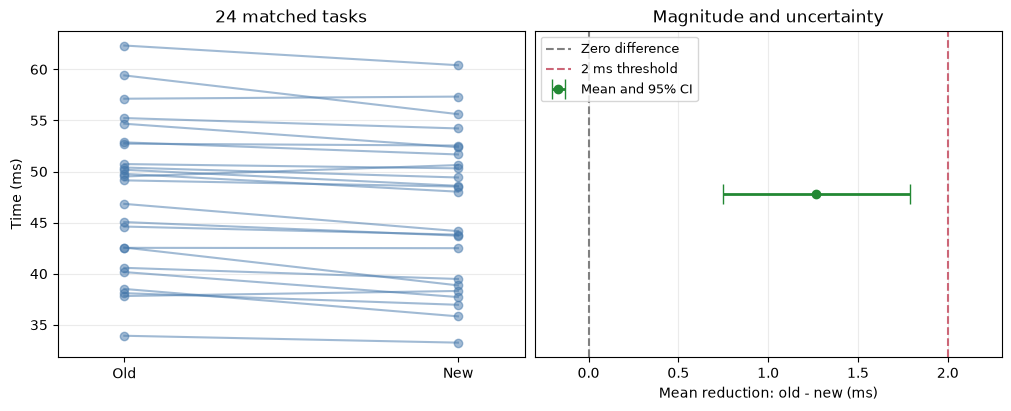

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
# 每条连线只连接同一个任务的两次时间，保留配对关系。
for old_value, new_value in zip(old_times, new_times):
    axes[0].plot([0, 1], [old_value, new_value], "o-", color="#4477AA", alpha=0.5)
axes[0].set_xticks([0, 1], ["Old", "New"])
axes[0].set_xlim(-0.2, 1.2)
axes[0].set_ylabel("Time (ms)")
axes[0].set_title("24 matched tasks")
axes[0].grid(axis="y", alpha=0.25)

# 右图显示平均收益的水平区间；两条竖线分别是零差异与实际收益门槛。
axes[1].errorbar(
    gain_mean,
    0,
    xerr=gain_margin,
    fmt="o",
    color="#228833",
    capsize=7,
    linewidth=2,
    label="Mean and 95% CI",
)
axes[1].axvline(0, color="gray", linestyle="--", label="Zero difference")
axes[1].axvline(useful_gain, color="#CC6677", linestyle="--", label="2 ms threshold")
axes[1].set_xlim(min(-0.3, gain_interval.low - 0.3), max(2.3, gain_interval.high + 0.3))
axes[1].set_ylim(-0.7, 0.7)
axes[1].set_yticks([])
axes[1].set_xlabel("Mean reduction: old - new (ms)")
axes[1].set_title("Magnitude and uncertainty")
axes[1].legend(loc="upper left", fontsize=9)
axes[1].grid(axis="x", alpha=0.25)
# 本次右图均值区间约 [0.748, 1.790] ms，全在零右侧，但仍低于 2 ms 门槛。
plt.show()
# 线段保留真实配对关系；误差线的长度由差值标准误与 t 分位数决定。

## 8 选学：多重比较与选择性分析

### 8.1 多次检验会改变整体错误率

假设事先安排 $m=20$ 个相互独立的检验，所有原假设都为真，各检验的第一类错误概率都是 $\alpha=0.05$。至少错误拒绝一次的概率称为这组检验的族错误率（family-wise error rate，FWER）：

$$P(\text{至少一次错误拒绝})
=1-P(\text{全部未拒绝})=1-(1-\alpha)^m.$$

最后一个等式需要各检验相互独立，不能直接套用于共享数据的任意比较。20 次时整体概率约为 0.642，并不是 0.05。

下面独立模拟 4000 组检验，每组含 20 个检验，每个检验使用 12 个独立标准正态观测。每个原假设都是均值为零；数组三个轴依次代表重复批次、检验编号和观测编号。

In [21]:
multiple_rng = np.random.default_rng(2108)
family_repetitions = 4000
test_count = 20
observations_per_test = 12
family_samples = multiple_rng.normal(
    0.0, 1.0, size=(family_repetitions, test_count, observations_per_test)
)
family_pvalues = ttest_1samp(family_samples, popmean=0.0, axis=2).pvalue
uncorrected_fwer = np.mean(np.any(family_pvalues < alpha, axis=1))

print("p 值矩阵形状：", family_pvalues.shape)  # 预期为 (4000, 20)。
print("未校正的理论族错误率：", 1 - (1 - alpha) ** test_count)  # 预期约为 0.641514。
print("未校正的模拟族错误率：", uncorrected_fwer)  # 本次固定种子下约为 0.64975。
# 每行是整组 20 个检验；先用 any 查找该组是否至少误拒绝一次，再求频率。

p 值矩阵形状： (4000, 20)
未校正的理论族错误率： 0.6415140775914581
未校正的模拟族错误率： 0.64975


### 8.2 Bonferroni 校正和完整报告

Bonferroni 方法把事先定义的 $m$ 个检验各自的阈值设为 $\alpha/m$。若其中 $m_0\le m$ 个原假设为真，且这些单次检验在该阈值下有效，记 $E_j$ 为错误拒绝第 $j$ 个真原假设的事件，则由概率的并集上界

$$P\!\left(\bigcup_{j=1}^{m_0}E_j\right)
\le\sum_{j=1}^{m_0}P(E_j)
\le m_0\frac{\alpha}{m}\le\alpha.$$

这个上界不需要各检验独立。也可把每个原始 p 值换成 $p_{\mathrm{adj}}=\min(mp,1)$，再与 $\alpha$ 比较。较严格的阈值控制整体错误率，同时会降低同一备择下的检出功效。

概率上界约束的是检验方法的真实错误概率，不是每次有限模拟得到的频率。模拟频率可能略高于 0.05，应结合模拟标准误观察；不需要更换种子把结果“调到”阈值以下。

校正需要定义完整的比较范围。反复尝试指标、子群、方向或停止时机，只报告最小 p 值，会使原先的单次检验解释失去依据。分析方案应尽量事先确定，报告保留所有相关分析；探索中发现的模式应明确标为探索结果，而不是伪装成事先设定的检验。

In [22]:
bonferroni_threshold = alpha / test_count
adjusted_pvalues = np.minimum(test_count * family_pvalues, 1.0)
corrected_fwer = np.mean(np.any(family_pvalues < bonferroni_threshold, axis=1))
corrected_theory = 1 - (1 - bonferroni_threshold) ** test_count
corrected_mc_se = np.sqrt(
    corrected_theory * (1 - corrected_theory) / family_repetitions
)
same_decisions = np.array_equal(
    family_pvalues < bonferroni_threshold, adjusted_pvalues < alpha
)

print("单次 Bonferroni 阈值：", bonferroni_threshold)  # 预期单次阈值为 0.05/20=0.0025，由检验次数决定。
print("校正后的模拟族错误率：", corrected_fwer)  # 本次固定种子下约为 0.05375。
print("本例独立机制下的理论值与模拟标准误：", corrected_theory, corrected_mc_se)  # 预期约为 0.0488301 0.00340756。
# 本次模拟族错误率高于理论值，差距约为 1.44 个模拟标准误。
print(
    "模拟频率偏离理论值的标准误倍数：",
    (corrected_fwer - corrected_theory) / corrected_mc_se,
)
print("阈值校正与 p 值校正结论相同：", same_decisions)  # 预期 True；两种校正写法对同一批 p 值给出相同决定。
# 理论上界不依赖检验独立；这里的乘积公式只因本模拟的独立设计才成立。

单次 Bonferroni 阈值： 0.0025
校正后的模拟族错误率： 0.05375
本例独立机制下的理论值与模拟标准误： 0.04883012474683324 0.0034075557098909603
模拟频率偏离理论值的标准误倍数： 1.4438135930943286
阈值校正与 p 值校正结论相同： True


## 本章小结

- 先说明总体参数、抽样设计、原假设、备择方向与显著性水平，再计算统计量和 p 值。
- 单样本检验比较一个均值与参考值；独立双样本检验比较两总体均值；配对检验分析对应差值。
- 等方差 t 检验与 Welch 检验的方差假设不同；Welch 使用近似自由度，不能修复观测不独立的问题。
- p 值不是原假设为真的概率。未拒绝不等于接受相等；统计显著性也不说明差异有实际价值。
- 第一类错误率是在原假设下讨论的；功效针对具体备择。比较多次时还要关注整体错误率和分析选择。

可以检查自己是否能回答：标准误来自哪些观测？检验方向是否事先确定？若 p 值不小，区间是否仍容纳较大的差异？

## 练习

（1）手算单样本检验。给定教学数据 4、5、6、7、8，假定它们来自独立正态观测，比较总体均值与参考值 5。先写出双侧假设，再计算均值、样本方差、标准误、自由度、t 值和 p 值，并与 ttest_1samp 核对。另行考虑“均值大于 5”的预先设定问题，解释为什么不能看过双侧结果后才改成单侧。

In [23]:
# 在这里完成练习 1。

（2）根据设计选择双样本方法。两组独立正态教学数据分别为 A=[8, 9, 10, 11]、B=[5, 8, 11, 14, 17]，总体方差未知且不假定相等。用 Welch 公式手算 A 减 B 的标准误、自由度、双侧 p 值和 95% 区间，再用 SciPy 核对。说明为什么样本方差不同不能单独证明总体方差不同，也不能因等方差检验的 p 值更小就改用它。

In [24]:
# 在这里完成练习 2。

（3）检查配对和边界。六个对象的改动前数据为 [20, 40, 60, 80, 100, 120]，相应改动后数据为 [19, 38, 60, 76, 97, 118]。假定各对象之间独立，差值满足正态模型，用“前减后”的差值完成配对检验、95% 区间及一段包含差异大小的解释。说明单独排序其中一列为何破坏设计；如果每一对差值都恰好为 2，普通 t 统计量的哪一步失去定义？

In [25]:
# 在这里完成练习 3。

（4）模拟多重比较。固定随机种子，每次让所有原假设都为真，每个检验使用 20 个独立标准正态观测，分别安排 10 个和 50 个独立检验，重复至少 2000 批。比较未校正与 Bonferroni 校正后的族错误率，并与相应独立情形理论值比较。说明为什么“全部原假设为真”的模拟只能检查错误率，不能据此报告对某个非零差异的功效。

In [26]:
# 在这里完成练习 4。

## 练习提示与解析

以下对应练习（3）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：以对象为单位先求前减后的差，再做单样本推断。

提示 2：检查差值的样本标准差；它是 t 统计量分母的一部分。

### 练习（3）参考解析

差值为 $(1,2,0,4,3,2)$，均值为 2，样本方差为 2，标准误为 $\sqrt{2/6}=1/\sqrt3$，自由度为 5。对双侧原假设“平均差为零”，$t=2\sqrt3\approx3.464$，双侧 p 值约 0.018；95% 区间约为 $[0.516,3.484]$。

在给定的独立对象与正态差值模型下，结果支持平均读数有所下降，估计下降量为 2，区间表示该平均差的不确定性。单独排序一列破坏对象对应，分析的差值随之改变。若差值全为 2，样本标准差为零，普通 t 统计量需除以零，不能继续套用上述有限 t 值与 t 分布计算。

## 参考与引用来源

| 网站 | 本章参考内容与定位 |
| --- | --- |
| MIT OpenCourseWare | 18.05 Spring 2022：[Reading 17b](https://ocw.mit.edu/courses/18-05-introduction-to-probability-and-statistics-spring-2022/mit18_05_s22_class17-prep-b.pdf) 第 3–4 节的假设检验组成、错误与功效；[Reading 18](https://ocw.mit.edu/courses/18-05-introduction-to-probability-and-statistics-spring-2022/mit18_05_s22_class18-prep.pdf) 第 3 节的设计与功效、第 5.4 节的单样本 t 检验；[Reading 19](https://ocw.mit.edu/courses/18-05-introduction-to-probability-and-statistics-spring-2022/mit18_05_s22_class19-prep.pdf) 第 4.3.1–4.3.3 节的等方差、Welch 与配对检验；[Reading 22](https://ocw.mit.edu/courses/18-05-introduction-to-probability-and-statistics-spring-2022/mit18_05_s22_class22-prep.pdf) 第 3 节的区间解释及第 5 节的 t 区间与检验关系。 |
| NIST/SEMATECH e-Handbook | [7.2.2](https://www.itl.nist.gov/div898/handbook/prc/section2/prc22.htm) 的单侧与双侧均值假设；[1.3.5.3](https://www.itl.nist.gov/div898/handbook/eda/section3/eda353.htm) 的双样本公式、等方差条件与 Welch 自由度；[7.3.1.1](https://www.itl.nist.gov/div898/handbook/prc/section3/prc311.htm) 的自然配对与差值分析；[7.4.6.3](https://www.itl.nist.gov/div898/handbook/prc/section4/prc463.htm) 的 Bonferroni 不等式及预定有限比较范围。 |
| American Statistical Association | [2016 年 3 月 7 日 p 值声明说明](https://www.amstat.org/asa/files/pdfs/p-valuestatement.pdf)，第 1–2 页的六项原则：p 值含义、效应大小、透明完整报告及选择性分析问题。 |
| SciPy | [ttest_1samp](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_1samp.html)、[ttest_ind](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html)、[ttest_rel](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_rel.html) 的 Parameters、Returns、Notes：axis、alternative、equal_var、自由度与 confidence_interval；[t](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html) 的 sf、cdf、ppf 和 pdf。 |
| NumPy | [Generator.normal](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.normal.html) 的 loc、scale、size 参数，用于已知正态机制的模拟。 |
| Matplotlib | [Axes.errorbar](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.errorbar.html) 的 xerr 与 capsize 参数，用于绘制差异的置信区间。 |